In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [2]:
csv_path = "data/new_flight_weather_merged.csv"
df = pd.read_csv(csv_path)

print("✅ CSV 로드 완료")
print("행 수:", len(df))
print("컬럼 수:", df.shape[1])
df.head()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11136\2761528833.py:2: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드 완료
행 수: 2836872
컬럼 수: 55


,Unnamed: 0,출발/도착,공항명,항공사,편명,도착지,일자,계획시간,예상시간,출발시간,...,현상번호(국내식),지면온도(°C),풍속_ms,풍향_deg,시정_m,전운량_okta,1층 운고(FT)_결측여부,운형(운형약어),최저운고(100m ),weather_datetime
0,5729485,출발,인천,홍콩항공,HX623,홍콩,20180101,5.0,2340.0,0.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
1,5729484,출발,인천,에미레이트항공,EK323,두바이,20180101,5.0,2350.0,6.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
2,5729487,출발,인천,에티하드,EY873,아부다비,20180101,15.0,15.0,14.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
3,5729488,출발,인천,타이에어아시아엑스,XJ703,돈므앙(방콕),20180101,20.0,20.0,25.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00
4,5729486,출발,인천,싱가폴항공,SQ603,싱가포르,20180101,5.0,0.0,28.0,...,0.0,NaN,0.514444,30.0,10000.0,0.0,NaN,NaN,NaN,2018-01-01 01:00:00


In [3]:
# =====================================================
# 🔍 수치형 / 범주형 컬럼 자동 분류
# =====================================================

# 🔢 수치형 컬럼
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 🏷 범주형 컬럼
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("\n🔢 수치형 컬럼 수:", len(num_cols))
print(num_cols)

print("\n🏷 범주형 컬럼 수:", len(cat_cols))
print(cat_cols)



🔢 수치형 컬럼 수: 36
['Unnamed: 0', '일자', '계획시간', '예상시간', '출발시간', '도착시간', '지연_분', '출발시간_clean', 'dep_hour', 'dep_min', 'dep_weekday', 'is_weekend', 'is_delay', '지점', '1층 운량(1/8)', '1층 운고(FT)', '기온(°C)', '이슬점온도(°C)', '해면기압(hPa)', '현지기압(hPa)', '강수량(mm)', '습도(%)', '증기압(hPa)', '일조(hr)', '일사(MJ/m2)', '적설(cm)', '3시간신적설(cm)', '중하층운량(10분위)', '현상번호(국내식)', '지면온도(°C)', '풍속_ms', '풍향_deg', '시정_m', '전운량_okta', '1층 운고(FT)_결측여부', '최저운고(100m )']

🏷 범주형 컬럼 수: 19
['출발/도착', '공항명', '항공사', '편명', '도착지', '구분', '상태', '지연원인', '출발지', '일자_dt', 'arrival_code', 'departure_datetime', 'flight_type', '지점명', '일시', '일기현상', '1층 운형', '운형(운형약어)', 'weather_datetime']


In [4]:
# =====================================================
# 🔍  결측치 점검
# =====================================================

print("\n🔢 수치형 컬럼 결측치 현황")
num_missing = (
    df[num_cols]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_cnt"})
)
num_missing["missing_ratio"] = num_missing["missing_cnt"] / len(df)
num_missing = num_missing[num_missing["missing_cnt"] > 0]

display(num_missing.sort_values("missing_cnt", ascending=False))


print("\n🏷 범주형 컬럼 결측치 현황")
cat_missing = (
    df[cat_cols]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_cnt"})
)
cat_missing["missing_ratio"] = cat_missing["missing_cnt"] / len(df)
cat_missing = cat_missing[cat_missing["missing_cnt"] > 0]

display(cat_missing.sort_values("missing_cnt", ascending=False))



🔢 수치형 컬럼 결측치 현황


,column,missing_cnt,missing_ratio
5,도착시간,2836872,1.000000e+00
35,최저운고(100m ),2820344,9.941739e-01
27,중하층운량(10분위),2288219,8.065993e-01
29,지면온도(°C),2255130,7.949354e-01
22,증기압(hPa),2252314,7.939428e-01
21,습도(%),2252281,7.939311e-01
15,1층 운고(FT),2145007,7.561169e-01
14,1층 운량(1/8),1754132,6.183332e-01
34,1층 운고(FT)_결측여부,1754132,6.183332e-01
31,풍향_deg,584846,2.061588e-01



🏷 범주형 컬럼 결측치 현황


,column,missing_cnt,missing_ratio
17,운형(운형약어),2820121,0.994095
7,지연원인,2384941,0.840694
16,1층 운형,1754132,0.618333
15,일기현상,29831,0.010515
6,상태,221,0.000078


In [5]:
# ✅ arrival_code 생성 (cat으로 쓸 거니까 문자열로)
if "도착지" in df.columns:
    df["arrival_code"] = (
        pd.to_numeric(df["도착지"], errors="coerce")
          .fillna(-1)
          .astype(int)
          .astype(str)
    )
else:
    df["arrival_code"] = "-1"


In [6]:
# =====================================================
# 5️⃣ 범주형 / 수치형 컬럼 (수치형 4개만 사용)
# =====================================================

cat_cols = [
    "항공사",
    "출발지",
    "arrival_code",
    "flight_type"
]
cat_cols = [c for c in cat_cols if c in df.columns]

# 🔢 수치형 (완전 고정)
num_cols = [
    "기온(°C)",
    "풍속_ms",
    "dep_hour",
    "dep_weekday",
    "is_weekend"
]


num_cols = [c for c in num_cols if c in df.columns]

print("\n📊 최종 수치형 컬럼 수:", len(num_cols))
print(num_cols)

print("\n🏷 최종 범주형 컬럼 수:", len(cat_cols))
print(cat_cols)



📊 최종 수치형 컬럼 수: 5
['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend']

🏷 최종 범주형 컬럼 수: 4
['항공사', '출발지', 'arrival_code', 'flight_type']


In [7]:
# =====================================================
# ⏱ departure_datetime 타입 변환 (필수)
# =====================================================
df["departure_datetime"] = pd.to_datetime(df["departure_datetime"])


In [8]:
# =====================================================
# 7️⃣ Train / Test 분리 (날짜 기준)
# =====================================================
df = df.sort_values("departure_datetime")

split_date = df["departure_datetime"].quantile(0.8)

train_df = df[df["departure_datetime"] <= split_date]
test_df  = df[df["departure_datetime"] > split_date]

print("\n📦 데이터 분리")
print("Train:", len(train_df), "Test:", len(test_df))

X_cols = num_cols + cat_cols

X_train = train_df[X_cols]
y_train = train_df["is_delay"]

X_test  = test_df[X_cols]
y_test  = test_df["is_delay"]


📦 데이터 분리
Train: 2269498 Test: 567374


In [9]:
# =====================================================
# 🔍 수치형 변수 ↔ is_delay (Spearman)
# =====================================================

corr_df = (
    train_df[num_cols + ["is_delay"]]
    .dropna()   # 상관계수 계산 가능한 행만 사용
    .corr(method="spearman")
)

result = (
    corr_df["is_delay"]
    .drop("is_delay")
    .reset_index()
)
result.columns = ["feature", "spearman_corr"]
result["abs_corr"] = result["spearman_corr"].abs()

print("📊 수치형 변수 ↔ is_delay Spearman 상관관계")
display(result.sort_values("abs_corr", ascending=False))


📊 수치형 변수 ↔ is_delay Spearman 상관관계


,feature,spearman_corr,abs_corr
2,dep_hour,0.136913,0.136913
1,풍속_ms,0.065533,0.065533
0,기온(°C),0.031811,0.031811
4,is_weekend,-0.014628,0.014628
3,dep_weekday,-0.004159,0.004159


In [10]:
# =====================================================
# 🔍 B️⃣ 범주형 변수 ↔ is_delay (Chi-square)
# =====================================================
from scipy.stats import chi2_contingency

cat_corr_results = []

for col in cat_cols:
    contingency = pd.crosstab(train_df[col], train_df["is_delay"])

    # 모든 값이 한쪽 클래스만 가지면 스킵
    if contingency.shape[1] < 2:
        continue

    chi2, p, _, _ = chi2_contingency(contingency)

    cat_corr_results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p
    })

cat_corr_df = (
    pd.DataFrame(cat_corr_results)
    .sort_values("chi2", ascending=False)
)

print("\n🏷 범주형 변수 Chi-square 결과")
display(cat_corr_df)



🏷 범주형 변수 Chi-square 결과


,feature,chi2,p_value
0,항공사,25835.114189,0.0
1,출발지,21975.446495,0.0
3,flight_type,3923.079589,0.0
2,arrival_code,0.000000,1.0


In [11]:
# =====================================================
# 8️⃣ 전처리 + 모델 정의 (결측치 포함)
# =====================================================
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# 🔢 수치형 전처리
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# 🏷 범주형 전처리
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
    max_iter=5000,
    n_jobs=-1,
    class_weight={0:1, 1:3}   # 또는 5
    ))
])


In [12]:
# =====================================================
# 9️⃣ 모델 학습
# =====================================================
model.fit(X_train, y_train)
print("\n✅ 모델 학습 완료")


✅ 모델 학습 완료


In [13]:
# =====================================================
# 🔟 평가
# =====================================================
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n📊 기본 성능")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))


📊 기본 성능
              precision    recall  f1-score   support

           0       0.76      0.92      0.83    421129
           1       0.41      0.17      0.24    146245

    accuracy                           0.72    567374
   macro avg       0.59      0.54      0.54    567374
weighted avg       0.67      0.72      0.68    567374

ROC-AUC: 0.6583228931932474
PR-AUC : 0.3718670963829095


In [14]:
# =====================================================
# 1️⃣1️⃣ Threshold 실험
# =====================================================
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    print(f"\n===== Threshold = {t} =====")
    y_pred_t = (y_prob >= t).astype(int)
    print(classification_report(y_test, y_pred_t))


===== Threshold = 0.3 =====
              precision    recall  f1-score   support

           0       0.84      0.52      0.65    421129
           1       0.34      0.72      0.47    146245

    accuracy                           0.57    567374
   macro avg       0.59      0.62      0.56    567374
weighted avg       0.71      0.57      0.60    567374


===== Threshold = 0.4 =====
              precision    recall  f1-score   support

           0       0.79      0.76      0.78    421129
           1       0.39      0.44      0.41    146245

    accuracy                           0.68    567374
   macro avg       0.59      0.60      0.59    567374
weighted avg       0.69      0.68      0.68    567374


===== Threshold = 0.5 =====
              precision    recall  f1-score   support

           0       0.76      0.92      0.83    421129
           1       0.41      0.17      0.24    146245

    accuracy                           0.72    567374
   macro avg       0.59      0.54      0.

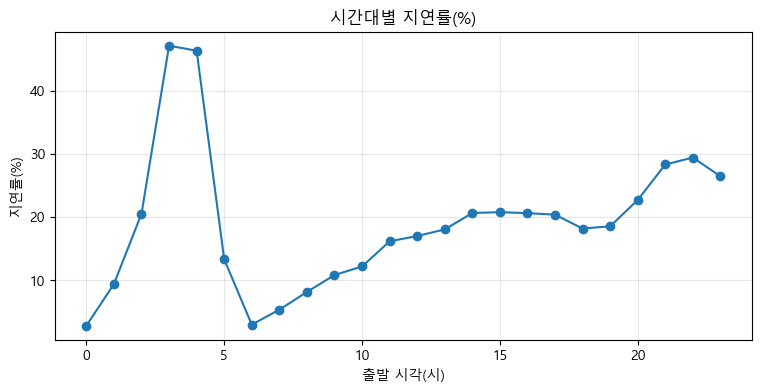

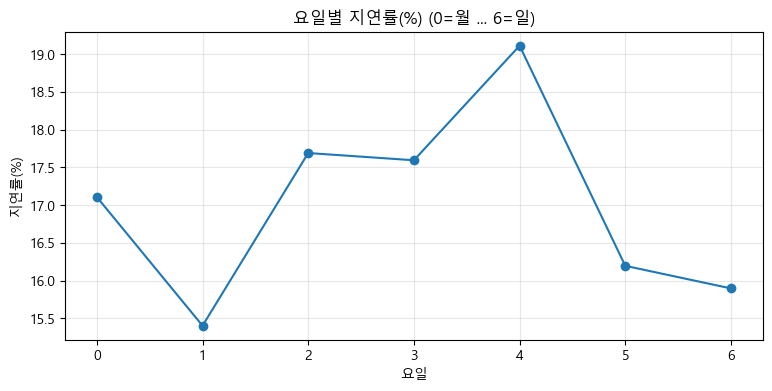

In [16]:
# y 라벨이 is_delay(0/1) 라고 가정
tmp = df.copy()

# 시간대별 지연률
rate_by_hour = tmp.groupby("dep_hour")["is_delay"].mean() * 100
plt.figure(figsize=(9,4))
plt.plot(rate_by_hour.index, rate_by_hour.values, marker="o")
plt.title("시간대별 지연률(%)")
plt.xlabel("출발 시각(시)")
plt.ylabel("지연률(%)")
plt.grid(True, alpha=0.3)
plt.show()

# 요일별 지연률
rate_by_wd = tmp.groupby("dep_weekday")["is_delay"].mean() * 100
plt.figure(figsize=(9,4))
plt.plot(rate_by_wd.index, rate_by_wd.values, marker="o")
plt.title("요일별 지연률(%) (0=월 ... 6=일)")
plt.xlabel("요일")
plt.ylabel("지연률(%)")
plt.grid(True, alpha=0.3)
plt.show()
